# 06_Loss_Landscape

## Learning Goal
Analyzing Loss Ravines and Spectral Bias.

## Prerequisites
Basic understanding of Calculus and Neural Networks.

## Theory & Mathematics
(Mathematical derivations and fundamental concepts)

## Implementation & Experiments


Training PINN for 5000 epochs...
Epoch 0 | Loss: 0.5704
Epoch 1000 | Loss: 0.0752
Epoch 2000 | Loss: 0.0691
Epoch 3000 | Loss: 0.0257
Epoch 4000 | Loss: 0.0623
Computing Frequency Spectra...
Computing analytical solution (this may take a few seconds)...


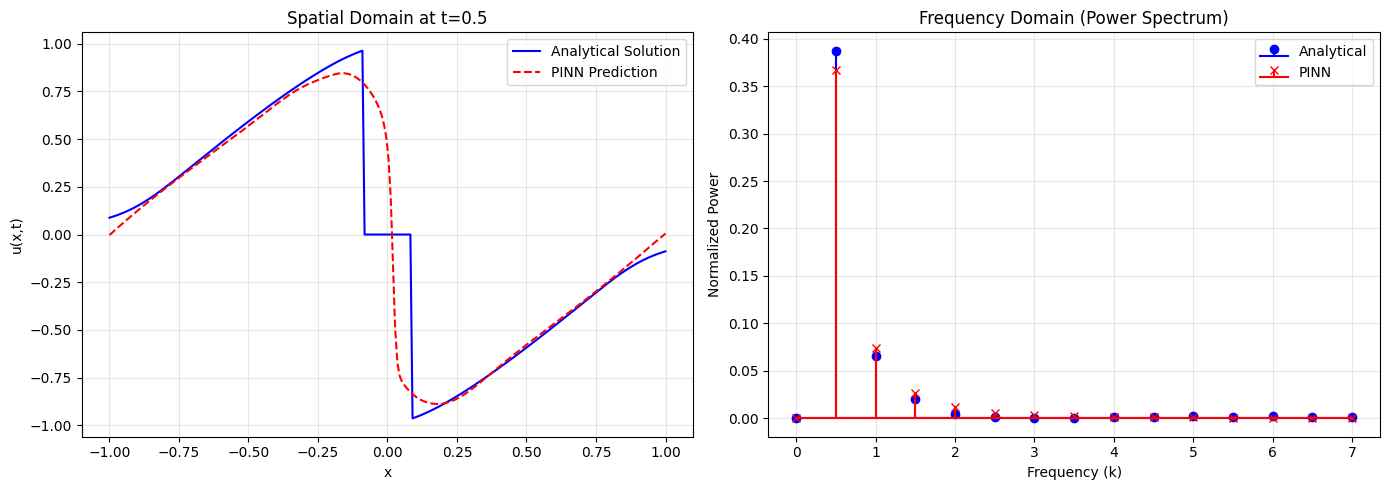

In [34]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# 1. Full PINN definition
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)
        self.act = nn.Tanh()
        
    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        z = self.act(self.fc1(z))
        z = self.act(self.fc2(z))
        z = self.act(self.fc3(z))
        return self.fc4(z)

def compute_derivatives(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u, u_t, u_x, u_xx

# 2. Robust Analytical Solution for Burgers (Cole-Hopf Transformation)
def analytical_burgers(x, t, nu):
    if t == 0:
        return -np.sin(np.pi * x)
    
    x = np.asarray(x)
    u = np.zeros_like(x)
    
    def u_single(x_val, t_val):
        # The correct Cole-Hopf integrand requires the heat kernel exp(-(x-xi)^2 / (4*nu*t))
        def integrand(xi):
            return np.exp(-np.cos(np.pi * xi) / (2 * np.pi * nu) - (x_val - xi)**2 / (4 * nu * t_val))
        def numerator_integrand(xi):
            return np.sin(np.pi * xi) * integrand(xi)
        
        # limit=100 allows quad to handle sharp peaks better
        denom, _ = quad(integrand, -1, 1, limit=100)
        num, _ = quad(numerator_integrand, -1, 1, limit=100)
        
        if abs(denom) < 1e-12:
            return 0.0
        return - num / denom
        
    for i, xi in enumerate(x):
        u[i] = u_single(xi, t)
    return u

# 3. Setup data
nu = 0.01 / np.pi
x_ic = torch.rand(200, 1, device=device) * 2 - 1
t_ic = torch.zeros(200, 1, device=device)
u_ic = -torch.sin(np.pi * x_ic)

t_bc = torch.rand(200, 1, device=device)
x_bc = torch.where(torch.rand_like(t_bc) < 0.5, -torch.ones_like(t_bc), torch.ones_like(t_bc))
u_bc = torch.zeros(200, 1, device=device)

x_f = torch.rand(1000, 1, device=device) * 2 - 1
t_f = torch.rand(1000, 1, device=device)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 4. Train for 5000 epochs
print("Training PINN for 5000 epochs...")
for epoch in range(5000):
    optimizer.zero_grad()
    u_pred_ic = model(x_ic, t_ic)
    u_pred_bc = model(x_bc, t_bc)
    u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
    
    loss_data = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
    r = u_t + u_pred_f * u_x - nu * u_xx
    loss_pde = torch.mean(r**2)
    
    total_loss = loss_data + loss_pde
    total_loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss.item():.4f}")

# 5. Compute Frequency Spectrum
print("Computing Frequency Spectra...")
x_grid = np.linspace(-1, 1, 256)
t_eval = 0.5 # Evaluate at t=0.5 where the shock is fully formed

# True solution
print("Computing analytical solution (this may take a few seconds)...")
u_true = analytical_burgers(x_grid, t_eval, nu)

# PINN solution
x_tensor = torch.tensor(x_grid, dtype=torch.float32).reshape(-1, 1).to(device)
t_tensor = torch.full_like(x_tensor, t_eval)
with torch.no_grad():
    u_pred = model(x_tensor, t_tensor).cpu().numpy().flatten()

# FFT Function
def compute_spectrum(u, N):
    fft_vals = np.fft.fft(u)
    ps = np.abs(fft_vals)**2
    ps = ps / np.sum(ps)
    freqs = np.fft.fftfreq(N, d=2/N)
    mask = freqs >= 0
    return freqs[mask], ps[mask]

freqs_true, ps_true = compute_spectrum(u_true, len(x_grid))
freqs_pred, ps_pred = compute_spectrum(u_pred, len(x_grid))

# 6. Visualization
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(x_grid, u_true, label='Analytical Solution', color='blue')
axs[0].plot(x_grid, u_pred, label='PINN Prediction', color='red', linestyle='dashed')
axs[0].set_title(f'Spatial Domain at t={t_eval}')
axs[0].set_xlabel('x')
axs[0].set_ylabel('u(x,t)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].stem(freqs_true[:15], ps_true[:15], linefmt='blue', markerfmt='bo', basefmt='b-', label='Analytical')
axs[1].stem(freqs_pred[:15], ps_pred[:15], linefmt='red', markerfmt='rx', basefmt='r-', label='PINN')
axs[1].set_title('Frequency Domain (Power Spectrum)')
axs[1].set_xlabel('Frequency (k)')
axs[1].set_ylabel('Normalized Power')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Training small PINN to reach optimization pathology...
Epoch 0 | Data: 0.5930 | PDE: 0.0048
Epoch 500 | Data: 0.1054 | PDE: 0.0500
Epoch 1000 | Data: 0.0713 | PDE: 0.0458
Epoch 1500 | Data: 0.0632 | PDE: 0.0419
Generating 2D Loss Landscape (this may take a minute)...


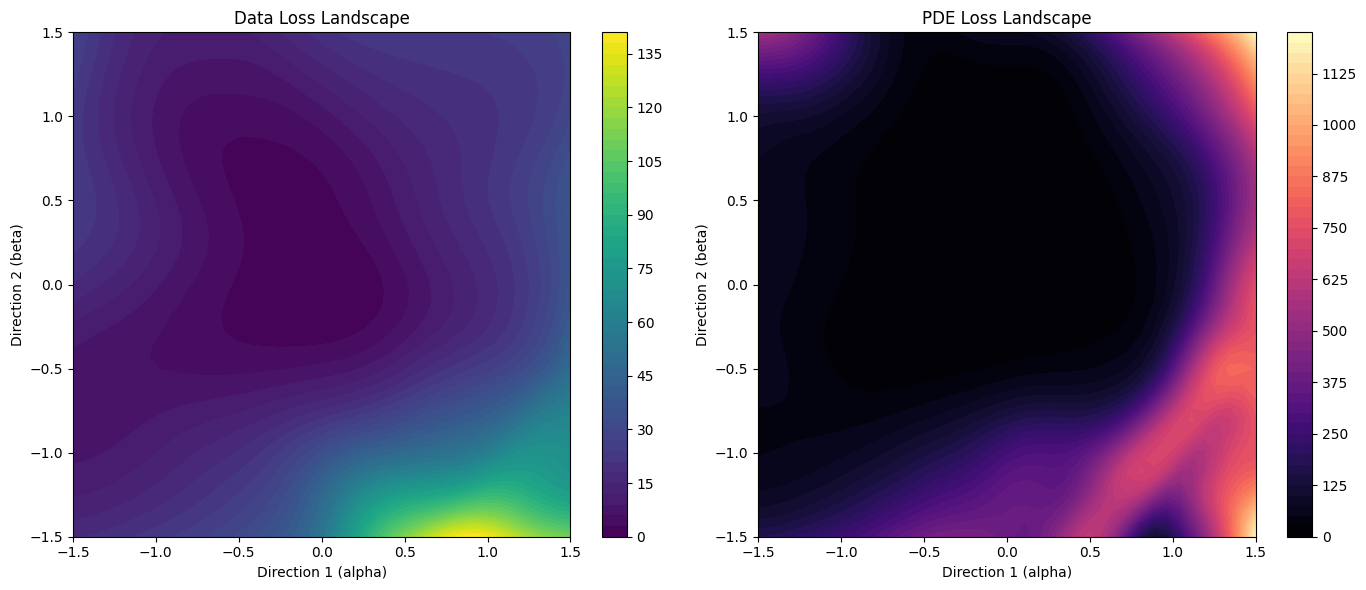

In [35]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# 1. Small PINN definition for fast landscape evaluation
class SmallPINN(nn.Module):
    def __init__(self):
        super(SmallPINN, self).__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 1)
        self.act = nn.Tanh()
        
    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        z = self.act(self.fc1(z))
        z = self.act(self.fc2(z))
        return self.fc3(z)

def compute_derivatives(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u, u_t, u_x, u_xx

# 2. Setup data
nu = 0.01 / np.pi
x_ic = torch.rand(100, 1, device=device) * 2 - 1
t_ic = torch.zeros(100, 1, device=device)
u_ic = -torch.sin(np.pi * x_ic)

t_bc = torch.rand(100, 1, device=device)
x_bc = torch.where(torch.rand_like(t_bc) < 0.5, -torch.ones_like(t_bc), torch.ones_like(t_bc))
u_bc = torch.zeros(100, 1, device=device)

x_f = torch.rand(500, 1, device=device) * 2 - 1
t_f = torch.rand(500, 1, device=device)

model = SmallPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 3. Train briefly to get to a "failure" point (a narrow ravine)
print("Training small PINN to reach optimization pathology...")
for epoch in range(2000):
    optimizer.zero_grad()
    u_pred_ic = model(x_ic, t_ic)
    u_pred_bc = model(x_bc, t_bc)
    u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
    
    loss_data = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
    r = u_t + u_pred_f * u_x - nu * u_xx
    loss_pde = torch.mean(r**2)
    
    total_loss = loss_data + loss_pde
    total_loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Data: {loss_data.item():.4f} | PDE: {loss_pde.item():.4f}")

# 4. Landscape Visualization Functions
def create_random_directions(model):
    directions = []
    weights_norm = 0
    for p in model.parameters():
        d = torch.randn_like(p)
        directions.append(d)
        weights_norm += torch.norm(p)**2
        
    weights_norm = torch.sqrt(weights_norm)
    
    dir_norm = 0
    for d in directions:
        dir_norm += torch.norm(d)**2
    dir_norm = torch.sqrt(dir_norm)
    
    # Scale directions to match the norm of the weights
    scale = weights_norm / dir_norm
    normalized_directions = [d * scale for d in directions]
    return normalized_directions

def apply_directions(model, directions, alpha, beta):
    # Apply perturbation: theta = theta* + alpha * d1 + beta * d2
    with torch.no_grad():
        for p, d1, d2 in zip(model.parameters(), directions[0], directions[1]):
            p.add_(alpha * d1 + beta * d2)

def remove_directions(model, directions, alpha, beta):
    # Undo perturbation to restore original weights
    with torch.no_grad():
        for p, d1, d2 in zip(model.parameters(), directions[0], directions[1]):
            p.sub_(alpha * d1 + beta * d2)

def compute_loss_landscape(model, directions, x_ic, t_ic, u_ic, x_bc, t_bc, u_bc, x_f, t_f, nu, alphas, betas):
    loss_data_grid = np.zeros((len(betas), len(alphas)))
    loss_pde_grid = np.zeros((len(betas), len(alphas)))
    
    for i, beta in enumerate(betas):
        for j, alpha in enumerate(alphas):
            apply_directions(model, directions, alpha, beta)
            
            u_pred_ic = model(x_ic, t_ic)
            u_pred_bc = model(x_bc, t_bc)
            u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
            
            ld = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
            r = u_t + u_pred_f * u_x - nu * u_xx
            lp = torch.mean(r**2)
            
            loss_data_grid[i, j] = ld.item()
            loss_pde_grid[i, j] = lp.item()
            
            remove_directions(model, directions, alpha, beta)
            
    return loss_data_grid, loss_pde_grid

# 5. Generate Landscape
print("Generating 2D Loss Landscape (this may take a minute)...")
alphas = np.linspace(-1.5, 1.5, 40)
betas = np.linspace(-1.5, 1.5, 40)
dir1 = create_random_directions(model)
dir2 = create_random_directions(model)
directions = [dir1, dir2]

ld_grid, lp_grid = compute_loss_landscape(model, directions, x_ic, t_ic, u_ic, x_bc, t_bc, u_bc, x_f, t_f, nu, alphas, betas)

# 6. Visualization
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Data Loss Landscape
A, B = np.meshgrid(alphas, betas)
c1 = axs[0].contourf(A, B, ld_grid, levels=50, cmap='viridis')
fig.colorbar(c1, ax=axs[0])
axs[0].set_title('Data Loss Landscape')
axs[0].set_xlabel('Direction 1 (alpha)')
axs[0].set_ylabel('Direction 2 (beta)')

# PDE Loss Landscape
c2 = axs[1].contourf(A, B, lp_grid, levels=50, cmap='magma')
fig.colorbar(c2, ax=axs[1])
axs[1].set_title('PDE Loss Landscape')
axs[1].set_xlabel('Direction 1 (alpha)')
axs[1].set_ylabel('Direction 2 (beta)')

plt.tight_layout()
plt.show()

Training PINN for visualization...
Generating 3D Spatio-Temporal Plot...


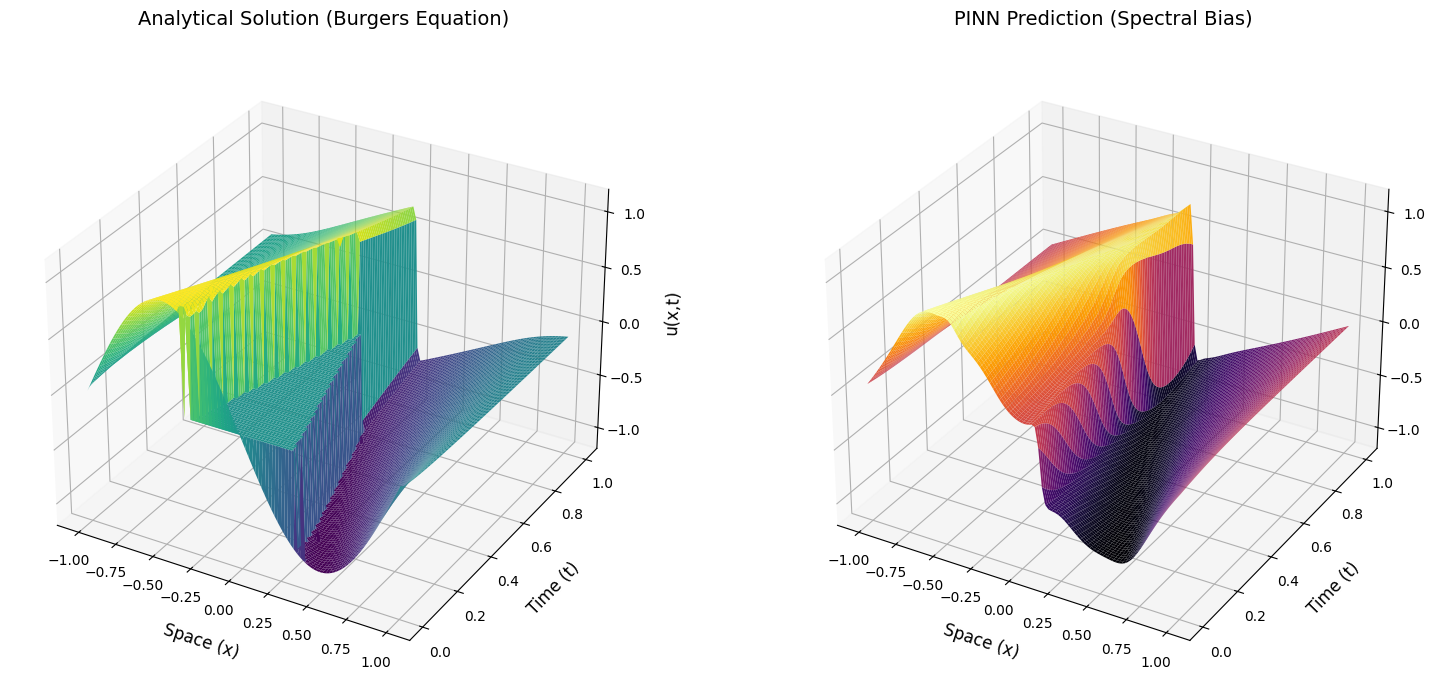

Generating 3D Loss Landscape Plot...


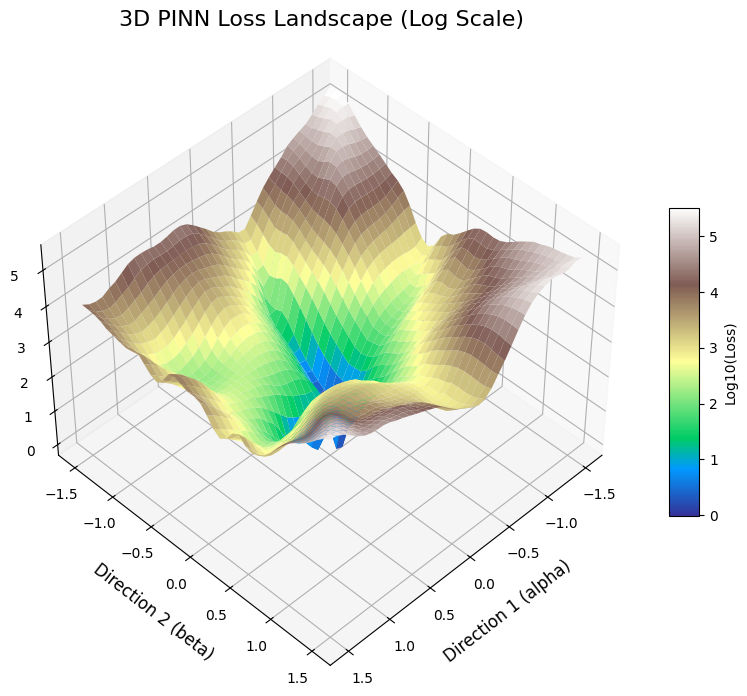

In [39]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import quad

# ---------------------------------------------------------
# 1. Setup & Model Definition (Must match previous milestones)
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)
        self.act = nn.Tanh()
        
    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        z = self.act(self.fc1(z))
        z = self.act(self.fc2(z))
        z = self.act(self.fc3(z))
        return self.fc4(z)

def compute_derivatives(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u, u_t, u_x, u_xx

# Robust Analytical Solution
def analytical_burgers(x, t, nu):
    if t == 0: return -np.sin(np.pi * x)
    x = np.asarray(x)
    u = np.zeros_like(x)
    def u_single(x_val, t_val):
        def integrand(xi): return np.exp(-np.cos(np.pi * xi) / (2 * np.pi * nu) - (x_val - xi)**2 / (4 * nu * t_val))
        def num_integrand(xi): return np.sin(np.pi * xi) * integrand(xi)
        denom, _ = quad(integrand, -1, 1, limit=100)
        num, _ = quad(num_integrand, -1, 1, limit=100)
        return - num / denom if abs(denom) > 1e-12 else 0.0
    for i, xi in enumerate(x): u[i] = u_single(xi, t)
    return u

# ---------------------------------------------------------
# 2. Train PINN (Briefly, to get the spectrally biased model)
# ---------------------------------------------------------
nu = 0.01 / np.pi
x_ic = torch.rand(200, 1, device=device) * 2 - 1
t_ic = torch.zeros(200, 1, device=device)
u_ic = -torch.sin(np.pi * x_ic)
t_bc = torch.rand(200, 1, device=device)
x_bc = torch.where(torch.rand_like(t_bc) < 0.5, -torch.ones_like(t_bc), torch.ones_like(t_bc))
u_bc = torch.zeros(200, 1, device=device)
x_f = torch.rand(1000, 1, device=device) * 2 - 1
t_f = torch.rand(1000, 1, device=device)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Training PINN for visualization...")
for epoch in range(3000):
    optimizer.zero_grad()
    u_pred_ic = model(x_ic, t_ic)
    u_pred_bc = model(x_bc, t_bc)
    u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
    loss_data = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
    r = u_t + u_pred_f * u_x - nu * u_xx
    loss_pde = torch.mean(r**2)
    (loss_data + loss_pde).backward()
    optimizer.step()

# ---------------------------------------------------------
# 3. Figure 1: 3D Spatio-Temporal Comparison
# ---------------------------------------------------------
print("Generating 3D Spatio-Temporal Plot...")
x_grid = np.linspace(-1, 1, 100)
t_grid = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_grid, t_grid)

# True solution
U_true = np.zeros_like(X)
for i, t_val in enumerate(t_grid):
    U_true[i, :] = analytical_burgers(x_grid, t_val, nu)

# PINN prediction
X_flat = torch.tensor(X.flatten(), dtype=torch.float32).reshape(-1, 1).to(device)
T_flat = torch.tensor(T.flatten(), dtype=torch.float32).reshape(-1, 1).to(device)
with torch.no_grad():
    U_pred = model(X_flat, T_flat).cpu().numpy().reshape(X.shape)

fig = plt.figure(figsize=(16, 7))

# Subplot 1: Analytical
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, T, U_true, cmap=cm.viridis, linewidth=0, antialiased=True, rstride=1, cstride=1)
ax1.set_title('Analytical Solution (Burgers Equation)', fontsize=14, pad=20)
ax1.set_xlabel('Space (x)', fontsize=12, labelpad=10)
ax1.set_ylabel('Time (t)', fontsize=12, labelpad=10)
ax1.set_zlabel('u(x,t)', fontsize=12, labelpad=10)
ax1.view_init(elev=30, azim=-60)
ax1.set_zlim(-1.2, 1.2)

# Subplot 2: PINN Prediction
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X, T, U_pred, cmap=cm.inferno, linewidth=0, antialiased=True, rstride=1, cstride=1)
ax2.set_title('PINN Prediction (Spectral Bias)', fontsize=14, pad=20)
ax2.set_xlabel('Space (x)', fontsize=12, labelpad=10)
ax2.set_ylabel('Time (t)', fontsize=12, labelpad=10)
ax2.set_zlabel('u(x,t)', fontsize=12, labelpad=10)
ax2.view_init(elev=30, azim=-60)
ax2.set_zlim(-1.2, 1.2)

plt.tight_layout()
plt.savefig('3d_spatiotemporal.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 4. Figure 2: 3D Loss Landscape (The Ravine)
# ---------------------------------------------------------
print("Generating 3D Loss Landscape Plot...")

# Create random directions (same as Milestone 7)
def create_directions(model):
    directions = []
    weights_norm = torch.sqrt(sum(torch.norm(p)**2 for p in model.parameters()))
    for p in model.parameters():
        d = torch.randn_like(p)
        dir_norm = torch.sqrt(sum(torch.norm(d)**2 for d in directions) + torch.norm(d)**2)
        scale = weights_norm / dir_norm
        directions.append(d * scale)
    return directions

def apply_directions(model, dirs, alpha, beta):
    with torch.no_grad():
        for p, d1, d2 in zip(model.parameters(), dirs[0], dirs[1]):
            p.add_(alpha * d1 + beta * d2)

def remove_directions(model, dirs, alpha, beta):
    with torch.no_grad():
        for p, d1, d2 in zip(model.parameters(), dirs[0], dirs[1]):
            p.sub_(alpha * d1 + beta * d2)

dir1 = create_directions(model)
dir2 = create_directions(model)
directions = [dir1, dir2]

alphas = np.linspace(-1.5, 1.5, 40)
betas = np.linspace(-1.5, 1.5, 40)
A, B = np.meshgrid(alphas, betas)
L_grid = np.zeros_like(A)

# Compute loss over grid
for i in range(len(betas)):
    for j in range(len(alphas)):
        apply_directions(model, directions, A[i,j], B[i,j])
        
        u_pred_ic = model(x_ic, t_ic)
        u_pred_bc = model(x_bc, t_bc)
        u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
        r = u_t + u_pred_f * u_x - nu * u_xx
        
        # Total loss
        loss = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2) + torch.mean(r**2)
        L_grid[i,j] = loss.item()
        remove_directions(model, directions, A[i,j], B[i,j])

# Plot 3D Landscape
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Use log scale for better visualization of the ravine
L_log = np.log10(L_grid + 1e-4)

surf = ax.plot_surface(A, B, L_log, cmap=cm.terrain, linewidth=0, antialiased=True, rstride=1, cstride=1)
ax.set_title('3D PINN Loss Landscape (Log Scale)', fontsize=16, pad=20)
ax.set_xlabel('Direction 1 (alpha)', fontsize=12, labelpad=10)
ax.set_ylabel('Direction 2 (beta)', fontsize=12, labelpad=10)
ax.set_zlabel('Log10(Loss)', fontsize=12, labelpad=10)
ax.view_init(elev=45, azim=45) # Angle to highlight the ravine

fig.colorbar(surf, shrink=0.5, aspect=10, label='Log10(Loss)')
plt.savefig('3d_loss_landscape.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary
This experiment demonstrates the specific concept in action.

## Further Reading
- Scientific Machine Learning & PINN surveys.